# One-Step LSTM Evaluation

В этом ноутбуке анализируется базовая one-step LSTM модель для задачи anomaly detection в HDFS логах. Модель получает скользящее окно из `EventId` и предсказывает следующий `EventId`. Затем качество оценивается на уровне `block_id`: если истинное следующее событие не попало в top-k предсказаний, это считается miss, а итоговый anomaly score блока равен доле таких miss внутри блока.

В текущем запуске используется early stopping: во время обучения выбирается checkpoint с минимальным `val_loss`, после чего именно этот checkpoint используется для расчёта validation/test scores.

## 1 Импорты и пути

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import precision_recall_curve

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "configs").exists() and (path / "src").exists():
            return path
    raise RuntimeError("Project root not found")


ROOT = find_project_root()
RUN_NAME = "token_e32_h64_l1_d00"
REPORT_DIR = ROOT / "reports" / "lstm_one_step" / RUN_NAME
TABLE_DIR = REPORT_DIR / "tables"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RUN:", RUN_NAME)
print("TABLE_DIR:", TABLE_DIR)

ROOT: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection
RUN: token_e32_h64_l1_d00
TABLE_DIR: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection/reports/lstm_one_step/token_e32_h64_l1_d00/tables


## 2 Загрузка результатов

In [2]:
validation_metrics = pd.read_csv(TABLE_DIR / "lstm_one_step_validation_metrics.csv")
test_metrics = pd.read_csv(TABLE_DIR / "lstm_one_step_test_metrics.csv")
thresholds = pd.read_csv(TABLE_DIR / "lstm_one_step_thresholds.csv")
val_scores = pd.read_csv(TABLE_DIR / "scores_val_lstm_one_step.csv")
test_scores = pd.read_csv(TABLE_DIR / "scores_test_lstm_one_step.csv")

history_path = TABLE_DIR / "lstm_one_step_history.json"
with history_path.open("r", encoding="utf-8") as file:
    history = json.load(file)

metrics = pd.concat(
    [validation_metrics.assign(split="validation"), test_metrics.assign(split="test")],
    ignore_index=True,
)
metric_columns = [
    "split",
    "model",
    "threshold",
    "f1",
    "precision",
    "recall",
    "fpr",
    "average_precision",
    "tn",
    "fp",
    "fn",
    "tp",
]
display(metrics[metric_columns].round(4))
display(thresholds.round(4))

print("Validation scores:", val_scores.shape)
print("Test scores:", test_scores.shape)
print("Best epoch:", history.get("best_epoch"))
print("Best val_loss:", round(history.get("best_val_loss"), 4))

,split,model,threshold,f1,precision,recall,fpr,average_precision,tn,fp,fn,tp
0,validation,lstm_one_step,0.087,0.6070,0.5511,0.6754,0.0312,0.5332,54080,1742,1028,2139
1,test,lstm_one_step,0.087,0.7061,0.7465,0.6699,0.0305,0.6714,54121,1702,2469,5011


,model,strategy,threshold,validation_best_f1
0,lstm_one_step,max_f1,0.087,0.607


Validation scores: (58989, 5)
Test scores: (63303, 5)
Best epoch: 2
Best val_loss: 0.2893


**Промежуточный вывод.** Для базовой one-step LSTM выбран checkpoint на 2-й эпохе, где достигается минимальный `val_loss`. На test split модель показывает умеренное качество: `F1 ≈ 0.706`, `precision ≈ 0.747`, `recall ≈ 0.670`, `FPR ≈ 0.031`. Баланс метрик показывает, что модель достаточно аккуратно ограничивает ложные срабатывания, но при этом пропускает часть аномальных блоков.

## 3 Динамика обучения и early stopping

,epoch,train_loss,val_loss,is_best
0,1,0.2085,0.2926,True
1,2,0.1895,0.2893,True
2,3,0.1881,0.2952,False


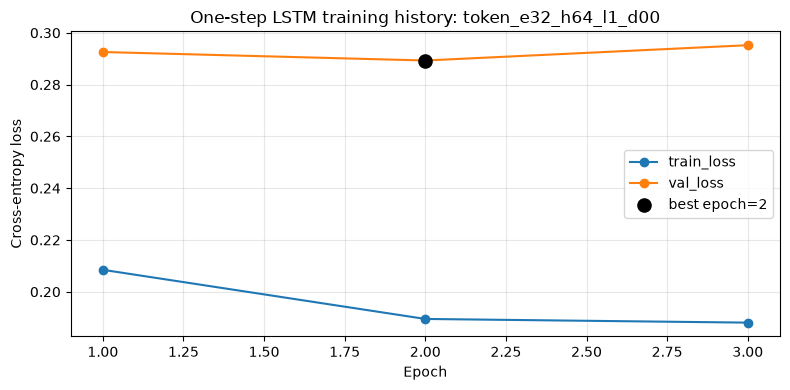

In [3]:
history_df = pd.DataFrame({key: value for key, value in history.items() if isinstance(value, list)})
display(history_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")

best_epoch = history.get("best_epoch")
if best_epoch is not None:
    best_row = history_df[history_df["epoch"] == best_epoch].iloc[0]
    ax.scatter(
        best_row["epoch"],
        best_row["val_loss"],
        s=90,
        color="black",
        zorder=5,
        label=f"best epoch={best_epoch}",
    )

ax.set_title(f"One-step LSTM training history: {RUN_NAME}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "one_step_training_loss.png", dpi=150)
plt.show()

**Промежуточный вывод.** Early stopping выбирает checkpoint с минимальным `val_loss`, а не последнюю эпоху. Для базовой модели минимум достигается на 2-й эпохе: дальше `train_loss` продолжает снижаться, но `val_loss` растёт. Это признак переобучения next-event задачи, поэтому использовать последнюю эпоху было бы хуже методологически.

## 4 Confusion matrices

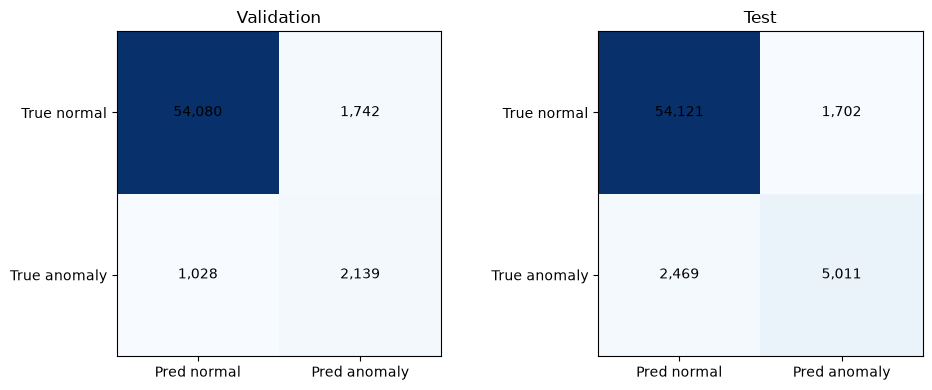

In [4]:
def plot_confusion_from_row(row: pd.Series, title: str, ax):
    matrix = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]], dtype=int)
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1], labels=["Pred normal", "Pred anomaly"])
    ax.set_yticks([0, 1], labels=["True normal", "True anomaly"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center", color="black")
    return im


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_from_row(validation_metrics.iloc[0], "Validation", axes[0])
plot_confusion_from_row(test_metrics.iloc[0], "Test", axes[1])
plt.tight_layout()
plt.savefig(FIG_DIR / "one_step_confusion_matrices.png", dpi=150)
plt.show()

**Промежуточный вывод.** На test split модель даёт `FP = 1702` и `FPR ≈ 0.031`, то есть число ложных срабатываний остаётся умеренным. При этом `FN = 2469`, поэтому модель пропускает заметную часть аномальных блоков. Это отражает основной trade-off текущего порога: precision выше recall.

## 5 Распределение block scores

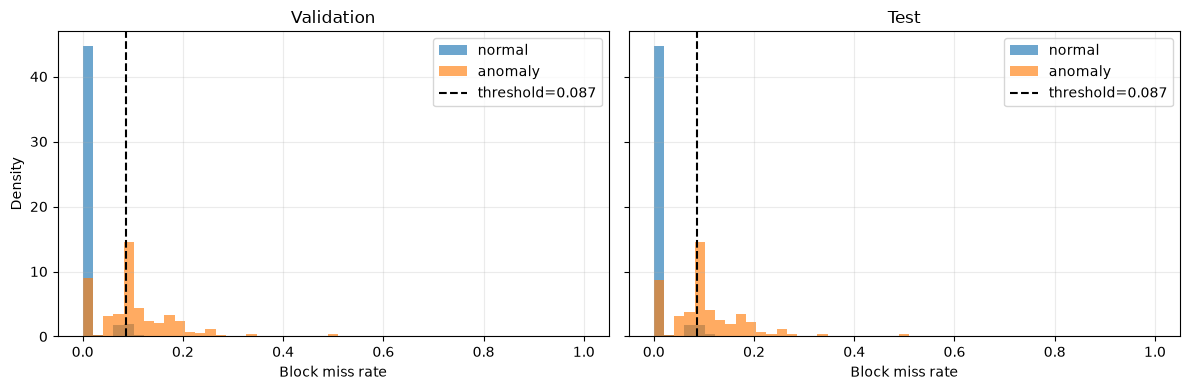

In [5]:
threshold = float(thresholds.loc[0, "threshold"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, split_name, scores in [(axes[0], "Validation", val_scores), (axes[1], "Test", test_scores)]:
    normal = scores.loc[scores["y_true"] == 0, "score"]
    anomaly = scores.loc[scores["y_true"] == 1, "score"]
    bins = np.linspace(0, max(scores["score"].max(), threshold) + 1e-9, 50)
    ax.hist(normal, bins=bins, alpha=0.65, label="normal", density=True)
    ax.hist(anomaly, bins=bins, alpha=0.65, label="anomaly", density=True)
    ax.axvline(
        threshold, color="black", linestyle="--", linewidth=1.5, label=f"threshold={threshold:.3f}"
    )
    ax.set_title(split_name)
    ax.set_xlabel("Block miss rate")
    ax.grid(alpha=0.25)
    ax.legend()
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig(FIG_DIR / "one_step_score_distributions.png", dpi=150)
plt.show()

In [6]:
def score_quantiles(scores: pd.DataFrame) -> pd.DataFrame:
    quantiles = [0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
    return (
        scores.groupby("y_true")["score"]
        .quantile(quantiles)
        .unstack()
        .rename(index={0: "normal", 1: "anomaly"})
    )


print("Validation score quantiles")
display(score_quantiles(val_scores).round(4))
print("Test score quantiles")
display(score_quantiles(test_scores).round(4))

Validation score quantiles


,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
y_true,,,,,,,,
normal,0.0,0.0000,0.0,0.0000,0.0,0.0769,0.1053,0.4
anomaly,0.0,0.0588,0.1,0.1429,0.2,0.2500,0.5000,1.0


Test score quantiles


,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
y_true,,,,,,,,
normal,0.0,0.0000,0.0,0.0000,0.0,0.0769,0.1111,0.4
anomaly,0.0,0.0625,0.1,0.1429,0.2,0.2500,0.5000,1.0


**Промежуточный вывод.** Нормальные блоки в основном концентрируются около нулевого `miss_rate`, а аномальные блоки смещены вправо. Значит, one-step LSTM действительно извлекает последовательный сигнал. Однако распределения всё ещё пересекаются около threshold, поэтому часть нормальных блоков становится FP, а часть аномальных блоков остаётся FN.

## 6 Precision-recall и threshold sweep

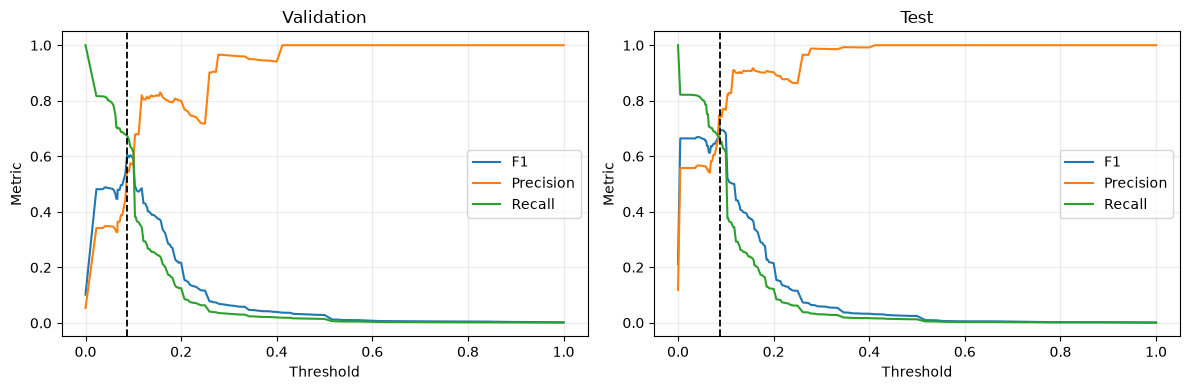

Best validation threshold by F1


,threshold,precision,recall,f1,fpr
30,0.087,0.5511,0.6754,0.607,0.0312


Best test threshold by F1, for diagnosis only


,threshold,precision,recall,f1,fpr
38,0.0857,0.7465,0.6701,0.7062,0.0305


In [7]:
def threshold_sweep(scores: pd.DataFrame) -> pd.DataFrame:
    thresholds_grid = np.unique(scores["score"].to_numpy())
    rows = []
    y_true = scores["y_true"].to_numpy()
    for thr in thresholds_grid:
        pred = (scores["score"].to_numpy() >= thr).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        tn = int(((pred == 0) & (y_true == 0)).sum())
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        fpr = fp / (fp + tn) if fp + tn else 0.0
        rows.append(
            {
                "threshold": float(thr),
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "fpr": fpr,
            }
        )
    return pd.DataFrame(rows)


val_sweep = threshold_sweep(val_scores)
test_sweep = threshold_sweep(test_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, title, sweep in [(axes[0], "Validation", val_sweep), (axes[1], "Test", test_sweep)]:
    ax.plot(sweep["threshold"], sweep["f1"], label="F1")
    ax.plot(sweep["threshold"], sweep["precision"], label="Precision")
    ax.plot(sweep["threshold"], sweep["recall"], label="Recall")
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1.3)
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "one_step_threshold_sweep.png", dpi=150)
plt.show()

best_val = val_sweep.loc[val_sweep["f1"].idxmax()]
best_test = test_sweep.loc[test_sweep["f1"].idxmax()]
print("Best validation threshold by F1")
display(best_val.to_frame().T.round(4))
print("Best test threshold by F1, for diagnosis only")
display(best_test.to_frame().T.round(4))

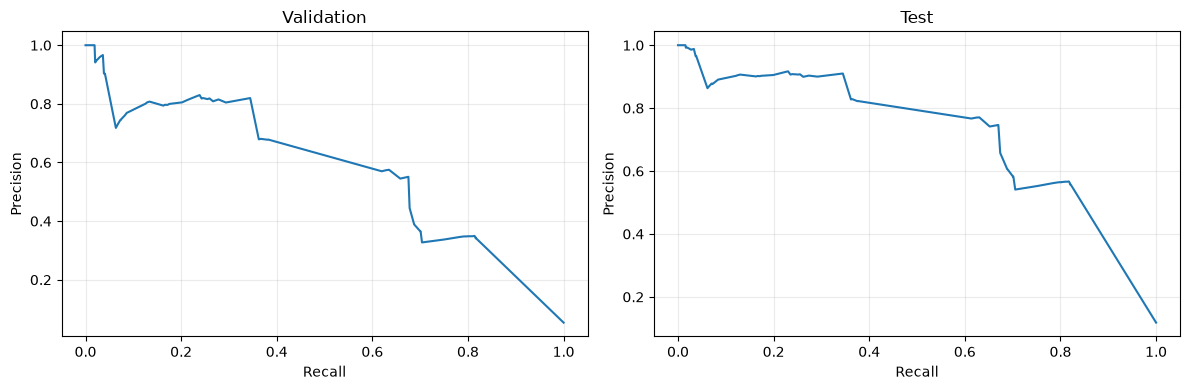

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, title, scores in [(axes[0], "Validation", val_scores), (axes[1], "Test", test_scores)]:
    precision, recall, _ = precision_recall_curve(scores["y_true"], scores["score"])
    ax.plot(recall, precision)
    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "one_step_precision_recall_curve.png", dpi=150)
plt.show()

**Промежуточный вывод.** Threshold выбирается честно по validation, а test используется только для финальной оценки. PR-кривая показывает, что anomaly score полезен, но качество чувствительно к выбранному порогу: повышение precision обычно сопровождается снижением recall.

## 7 False positives и false negatives

In [9]:
def add_predictions(scores: pd.DataFrame, threshold: float) -> pd.DataFrame:
    result = scores.copy()
    result["y_pred"] = (result["score"] >= threshold).astype(int)
    result["error_type"] = np.select(
        [
            (result["y_true"] == 0) & (result["y_pred"] == 1),
            (result["y_true"] == 1) & (result["y_pred"] == 0),
            (result["y_true"] == 1) & (result["y_pred"] == 1),
            (result["y_true"] == 0) & (result["y_pred"] == 0),
        ],
        ["FP", "FN", "TP", "TN"],
        default="unknown",
    )
    return result


test_pred = add_predictions(test_scores, threshold)
error_counts = (
    test_pred["error_type"].value_counts().reindex(["TN", "FP", "FN", "TP"]).fillna(0).astype(int)
)
display(error_counts.to_frame("count"))

print("Top false positives by score")
display(
    test_pred[test_pred["error_type"] == "FP"]
    .sort_values(["score", "num_windows"], ascending=[False, False])
    .head(15)
)

print("False negatives with the lowest scores")
display(
    test_pred[test_pred["error_type"] == "FN"]
    .sort_values(["score", "num_windows"], ascending=[True, False])
    .head(15)
)

,count
error_type,
TN,54121
FP,1702
FN,2469
TP,5011


Top false positives by score


,block_id,y_true,score,num_windows,num_misses,y_pred,error_type
18114,blk_-5952977669352948796,0,0.400000,5,2,1,FP
10173,blk_-3748302879255540217,0,0.333333,3,1,1,FP
50945,blk_6537303783042552463,0,0.333333,3,1,1,FP
6507,blk_-2777559315207113594,0,0.272727,11,3,1,FP
9376,blk_-3531912621358459370,0,0.272727,11,3,1,FP
9824,blk_-3654151485017263910,0,0.272727,11,3,1,FP
28097,blk_-8654272410196140483,0,0.272727,11,3,1,FP
42112,blk_4184829274856974115,0,0.272727,11,3,1,FP
55960,blk_7721981551851594957,0,0.272727,11,3,1,FP
56443,blk_7826982459275624658,0,0.272727,11,3,1,FP


False negatives with the lowest scores


,block_id,y_true,score,num_windows,num_misses,y_pred,error_type
18485,blk_-6050329559397303639,1,0.0,34,0,0,FN
39676,blk_3526305887089294017,1,0.0,34,0,0,FN
58075,blk_8176753742210481335,1,0.0,28,0,0,FN
60408,blk_8674413826212569730,1,0.0,28,0,0,FN
61141,blk_8838837797955603502,1,0.0,28,0,0,FN
62925,blk_9201186293149821635,1,0.0,28,0,0,FN
57429,blk_8049541706188251589,1,0.0,27,0,0,FN
57915,blk_8147760841047876333,1,0.0,27,0,0,FN
62673,blk_9146865366890002551,1,0.0,27,0,0,FN
57848,blk_8137896293132792722,1,0.0,26,0,0,FN


**Промежуточный вывод.** FP с высоким score - это нормальные блоки, в которых модель часто не угадывает следующий event в top-k. FN с низким score - аномальные блоки, последовательность которых выглядит нормальной для one-step top-k miss scoring. Это ограничение самого scoring: он хорошо ловит непривычные переходы, но не все типы аномалий обязаны проявляться как частые top-k misses.

## 8 Связь ошибок с длиной блока

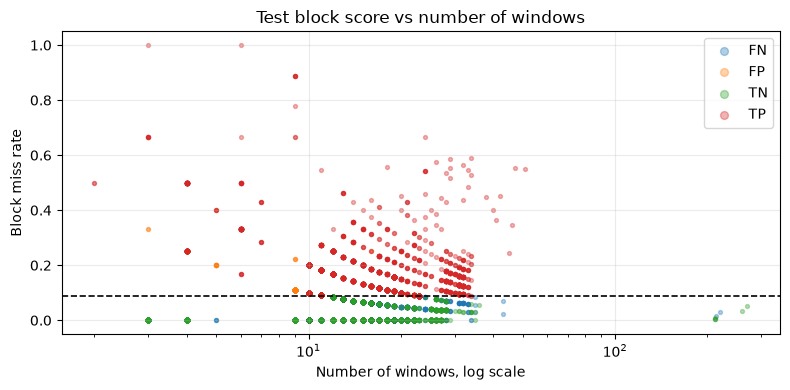

,blocks,score_mean,score_median,windows_median,windows_p95
error_type,,,,,
TN,54121,0.0042,0.0000,9.0,18.00
FP,1702,0.1135,0.1000,10.0,17.95
FN,2469,0.0281,0.0000,16.0,24.00
TP,5011,0.1483,0.1176,12.0,31.00


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for error_type, group in test_pred.groupby("error_type"):
    ax.scatter(group["num_windows"], group["score"], s=8, alpha=0.35, label=error_type)
ax.axhline(threshold, color="black", linestyle="--", linewidth=1.2)
ax.set_xscale("log")
ax.set_xlabel("Number of windows, log scale")
ax.set_ylabel("Block miss rate")
ax.set_title("Test block score vs number of windows")
ax.grid(alpha=0.25)
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "one_step_score_vs_num_windows.png", dpi=150)
plt.show()

summary_by_error = (
    test_pred.groupby("error_type")
    .agg(
        blocks=("block_id", "size"),
        score_mean=("score", "mean"),
        score_median=("score", "median"),
        windows_median=("num_windows", "median"),
        windows_p95=("num_windows", lambda s: s.quantile(0.95)),
    )
    .reindex(["TN", "FP", "FN", "TP"])
)
display(summary_by_error.round(4))

**Промежуточный вывод.** `miss_rate` чувствителен к числу окон в блоке: на коротких блоках один miss сильнее меняет итоговую долю ошибок. При этом ошибки встречаются не только среди самых коротких блоков, значит проблема не сводится только к длине последовательности.

## Итоговый вывод

One-step LSTM подтверждает, что порядок событий в HDFS логах содержит полезный сигнал для anomaly detection. Базовая модель использует early stopping и выбирает checkpoint с минимальным `val_loss` на 2-й эпохе, после чего именно этот checkpoint применяется для расчёта validation/test scores.

На test split модель показывает умеренно хорошее качество: `F1 ≈ 0.706`, `precision ≈ 0.747`, `recall ≈ 0.670`, `FPR ≈ 0.031`, `average precision ≈ 0.671`. Модель достаточно хорошо ограничивает ложные срабатывания, но recall остаётся ниже precision: часть аномальных блоков получает низкий `miss_rate` и не пересекает выбранный threshold.

Таким образом, one-step LSTM стоит рассматривать как production-like sequential baseline. Он работает честнее табличных моделей, потому что использует последовательное поступление событий, но его scoring остаётся достаточно грубым: весь блок описывается долей top-k misses. Для дальнейшего улучшения качества логично отдельно сравнить несколько one-step архитектур, а затем перейти к many-to-many LSTM и более выразительным scoring strategies, таким как `nll_mean`, `nll_p95` и `nll_max`.